In [9]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv('D:\Projects\sales_analytics_project\data\Sample - Superstore.csv',encoding='latin1')

# Data Inspection
print(f"Rows:{df.shape[0]}")
print(f"Columns:{df.shape[1]}")
print(f"\nColumn Names:\n{df.columns.tolist()}")
print(f"\nFirst 3 rows:{df.head(3)}")


Rows:9994
Columns:21

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 3 rows:   Row ID        Order ID Order Date   Ship Date     Ship Mode Customer ID  \
0       1  CA-2016-152156  11/8/2016  11/11/2016  Second Class    CG-12520   
1       2  CA-2016-152156  11/8/2016  11/11/2016  Second Class    CG-12520   
2       3  CA-2016-138688  6/12/2016   6/16/2016  Second Class    DV-13045   

     Customer Name    Segment        Country         City  ... Postal Code  \
0      Claire Gute   Consumer  United States    Henderson  ...       42420   
1      Claire Gute   Consumer  United States    Henderson  ...       42420   
2  Darrin Van Huff  Corporate  United States  Los Angeles  ...       90036   

   Region       Product ID         Category Sub-Category  \
0   

<>:8: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:8: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
C:\Users\harjo\AppData\Local\Temp\ipykernel_6856\1730203445.py:8: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
  df = pd.read_csv('D:\Projects\sales_analytics_project\data\Sample - Superstore.csv',encoding='latin1')


In [14]:
# Data Cleaning
df.columns = df.columns.str.strip()
print(df.isnull().sum())
df = df.drop_duplicates()
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [15]:
# Creating new columns 
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100
df['Shipping_Days'] = (df['Ship Date'] - df['Order Date']).dt.days


In [16]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year',
       'Month', 'Profit_Margin', 'Shipping_Days'],
      dtype='str')

In [17]:
df.to_csv('D:\Projects\sales_analytics_project\data\Cleaned_Superstore.csv',index=False)
print('Done')
print(f'Saved {len(df):,} rows with {len(df.columns)} columns')

Done
Saved 9,994 rows with 25 columns


<>:1: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:1: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
C:\Users\harjo\AppData\Local\Temp\ipykernel_6856\30599372.py:1: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
  df.to_csv('D:\Projects\sales_analytics_project\data\Cleaned_Superstore.csv',index=False)


In [29]:
# KPI
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
avg_margin = df['Profit_Margin'].mean()
print(f'Total Sales: ${total_sales:,.2f} \nTotal Profit: ${total_profit:,.2f} \nAverage Margin: ${avg_margin:,.2f}')

Total Sales: $2,297,200.86 
Total Profit: $286,397.02 
Average Margin: $12.03


SALES BY CATEGORY
Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


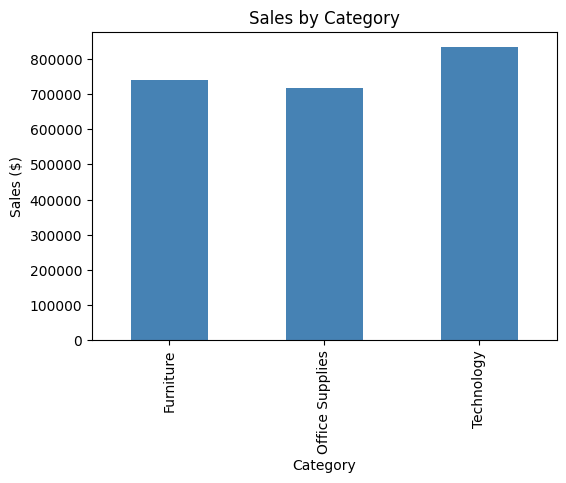

In [ ]:
# Sales By Product Category

# Which category sells the most?
category_sales = df.groupby('Category')['Sales'].sum()

print('SALES BY CATEGORY')ls
print(category_sales)

plt.figure(figsize=(6,4))
category_sales.plot(kind='bar',color='steelblue')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales ($)')
plt.show()

PROFIT BY REGION
Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


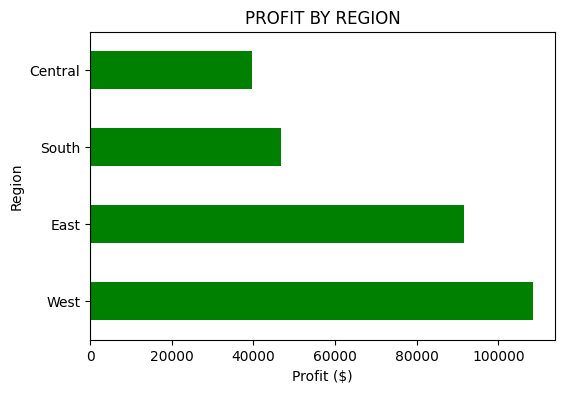

In [49]:
# Profit by Margin

# Which region makes most profit?
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

print('PROFIT BY REGION')
print(region_profit)

plt.figure(figsize=(6,4))
region_profit.plot(kind='barh',color='green')
plt.title('PROFIT BY REGION')
plt.xlabel('Profit ($)')
plt.show()

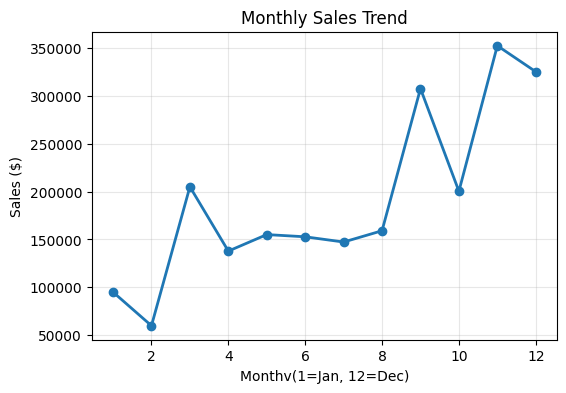

Best month: Month 11 ($352,461.07)
Worst month: Month 2 ($59,751.25)


In [52]:
# Monthly Sales Trend

# Sales pattern across months
monthly = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(6,4))
plt.plot(monthly.index,monthly.values,marker='o',linewidth=2)
plt.title('Monthly Sales Trend')
plt.xlabel('Monthv(1=Jan, 12=Dec)')
plt.ylabel('Sales ($)')
plt.grid(True, alpha=0.3)
plt.show()

print(f'Best month: Month {monthly.idxmax()} (${monthly.max():,.2f})')
print(f'Worst month: Month {monthly.idxmin()} (${monthly.min():,.2f})')
    

In [54]:
# Top 5 Products by Profit

#Best selling products 

top_products = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(5)

print('TOP 5 MOST PROFITABLE PRODUCTS')
print(top_products)

TOP 5 MOST PROFITABLE PRODUCTS
Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Name: Profit, dtype: float64
